In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\TechTroniX\Downloads\WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nFirst rows:")
print(df.head())
print("\nInfo:")
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())
print("\nChurn distribution:")
print(df['Churn'].value_counts())

Shape: (7043, 21)

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

First rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1 

In [2]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("Missing TotalCharges after conversion:", df['TotalCharges'].isnull().sum())

df['TotalCharges'] = df['TotalCharges'].fillna(0)

df = df.drop_duplicates()

df['ChurnFlag'] = (df['Churn'] == 'Yes').astype(int)

print("\nShape after cleaning:", df.shape)
print("\nData types check:")
print(df[['TotalCharges', 'MonthlyCharges', 'tenure', 'ChurnFlag']].dtypes)
print("\nOverall churn rate:", f"{df['ChurnFlag'].mean()*100:.1f}%")

Missing TotalCharges after conversion: 11

Shape after cleaning: (7043, 22)

Data types check:
TotalCharges      float64
MonthlyCharges    float64
tenure              int64
ChurnFlag           int64
dtype: object

Overall churn rate: 26.5%


In [3]:
print("=== Churn Rate by Contract ===")
print((df.groupby('Contract')['ChurnFlag'].mean()*100).round(1).sort_values(ascending=False))

print("\n=== Churn Rate by InternetService ===")
print((df.groupby('InternetService')['ChurnFlag'].mean()*100).round(1).sort_values(ascending=False))

print("\n=== Churn Rate by PaymentMethod ===")
print((df.groupby('PaymentMethod')['ChurnFlag'].mean()*100).round(1).sort_values(ascending=False))

print("\n=== Churn Rate by TechSupport ===")
print((df.groupby('TechSupport')['ChurnFlag'].mean()*100).round(1).sort_values(ascending=False))

print("\n=== Churn Rate: Senior Citizen ===")
print((df.groupby('SeniorCitizen')['ChurnFlag'].mean()*100).round(1))

print("\n=== Tenure: churned vs stayed ===")
print(df.groupby('Churn')['tenure'].mean().round(1))

print("\n=== Monthly Charges: churned vs stayed ===")
print(df.groupby('Churn')['MonthlyCharges'].mean().round(1))

=== Churn Rate by Contract ===
Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: ChurnFlag, dtype: float64

=== Churn Rate by InternetService ===
InternetService
Fiber optic    41.9
DSL            19.0
No              7.4
Name: ChurnFlag, dtype: float64

=== Churn Rate by PaymentMethod ===
PaymentMethod
Electronic check             45.3
Mailed check                 19.1
Bank transfer (automatic)    16.7
Credit card (automatic)      15.2
Name: ChurnFlag, dtype: float64

=== Churn Rate by TechSupport ===
TechSupport
No                     41.6
Yes                    15.2
No internet service     7.4
Name: ChurnFlag, dtype: float64

=== Churn Rate: Senior Citizen ===
SeniorCitizen
0    23.6
1    41.7
Name: ChurnFlag, dtype: float64

=== Tenure: churned vs stayed ===
Churn
No     37.6
Yes    18.0
Name: tenure, dtype: float64

=== Monthly Charges: churned vs stayed ===
Churn
No     61.3
Yes    74.4
Name: MonthlyCharges, dtype: float64


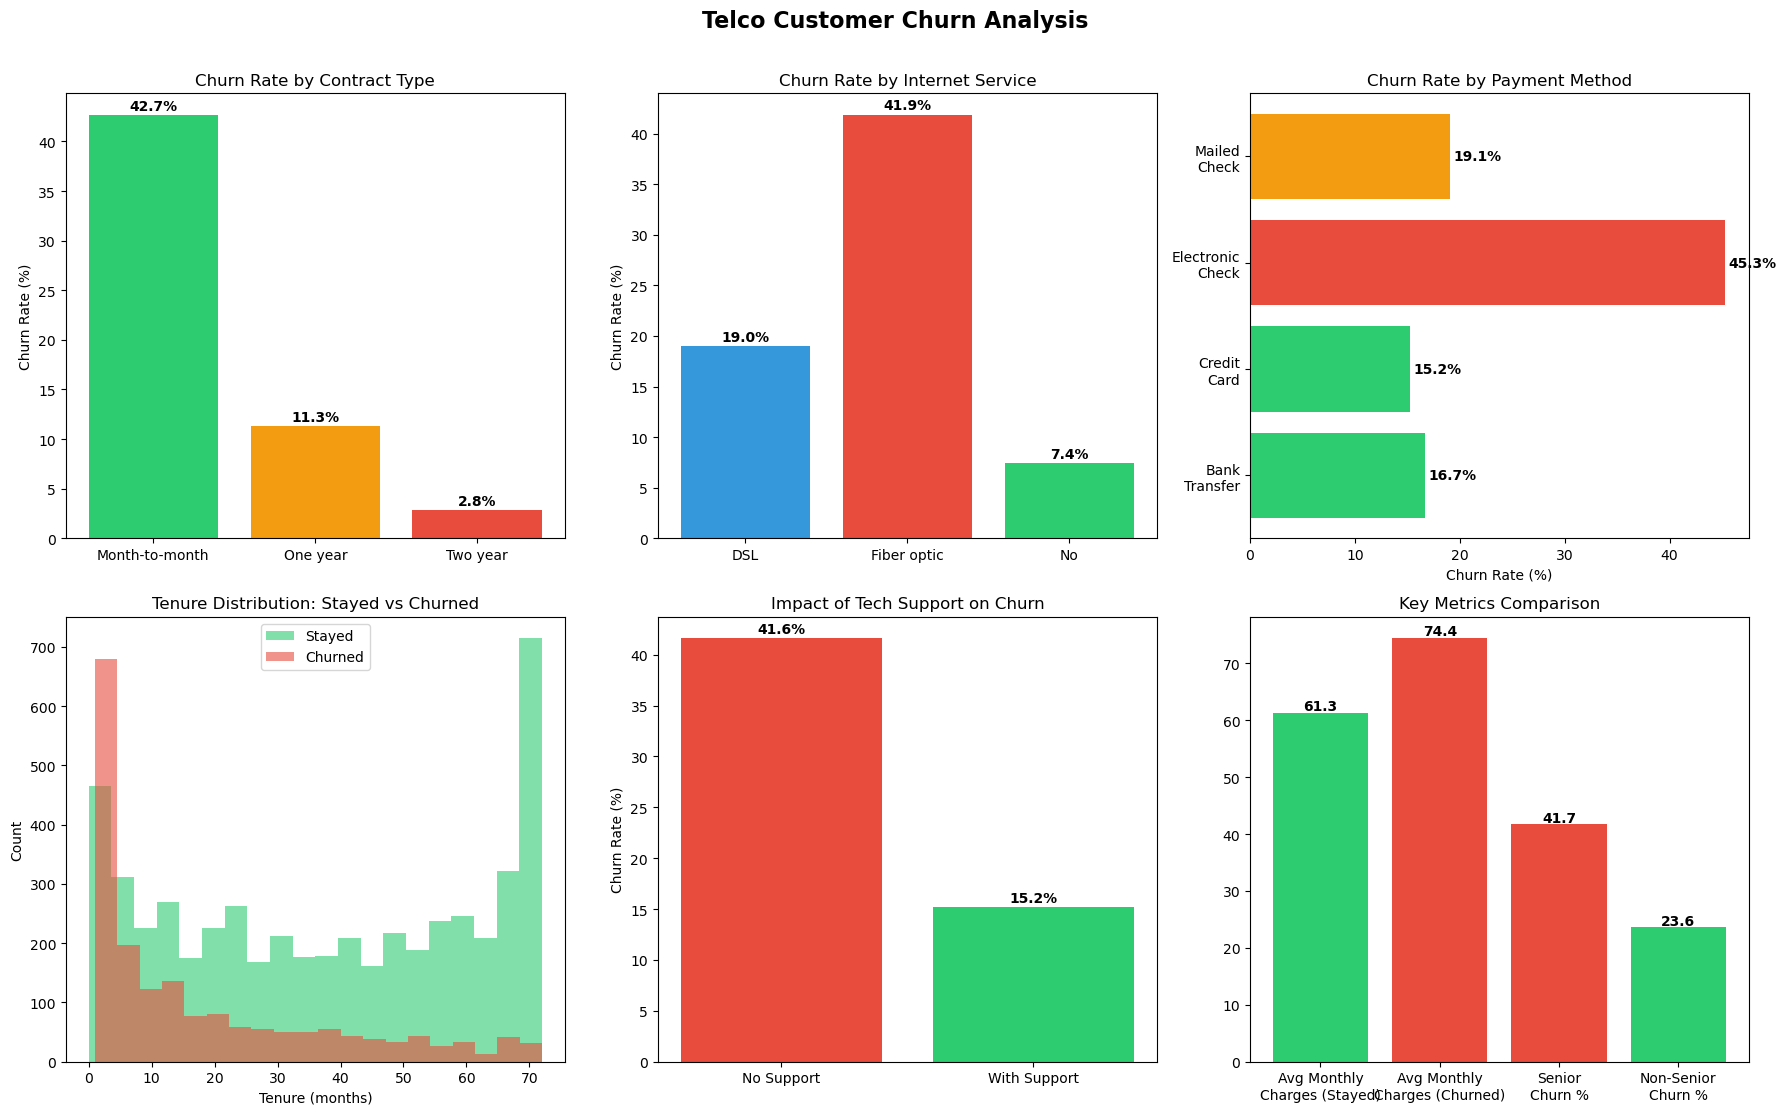

Saved successfully.


In [4]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Telco Customer Churn Analysis', fontsize=16, fontweight='bold', y=1.01)

contract_churn = df.groupby('Contract')['ChurnFlag'].mean() * 100
axes[0,0].bar(contract_churn.index, contract_churn.values, color=['#2ecc71','#f39c12','#e74c3c'])
axes[0,0].set_title('Churn Rate by Contract Type')
axes[0,0].set_ylabel('Churn Rate (%)')
for i, v in enumerate(contract_churn.values):
    axes[0,0].text(i, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold')

internet_churn = df.groupby('InternetService')['ChurnFlag'].mean() * 100
axes[0,1].bar(internet_churn.index, internet_churn.values, color=['#3498db','#e74c3c','#2ecc71'])
axes[0,1].set_title('Churn Rate by Internet Service')
axes[0,1].set_ylabel('Churn Rate (%)')
for i, v in enumerate(internet_churn.values):
    axes[0,1].text(i, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold')

payment_churn = df.groupby('PaymentMethod')['ChurnFlag'].mean() * 100
short_labels = ['Bank\nTransfer', 'Credit\nCard', 'Electronic\nCheck', 'Mailed\nCheck']
axes[0,2].barh(short_labels, payment_churn.values, color=['#2ecc71','#2ecc71','#e74c3c','#f39c12'])
axes[0,2].set_title('Churn Rate by Payment Method')
axes[0,2].set_xlabel('Churn Rate (%)')
for i, v in enumerate(payment_churn.values):
    axes[0,2].text(v+0.3, i, f'{v:.1f}%', va='center', fontweight='bold')

tenure_no = df[df['Churn']=='No']['tenure']
tenure_yes = df[df['Churn']=='Yes']['tenure']
axes[1,0].hist(tenure_no, bins=20, alpha=0.6, color='#2ecc71', label='Stayed')
axes[1,0].hist(tenure_yes, bins=20, alpha=0.6, color='#e74c3c', label='Churned')
axes[1,0].set_title('Tenure Distribution: Stayed vs Churned')
axes[1,0].set_xlabel('Tenure (months)')
axes[1,0].set_ylabel('Count')
axes[1,0].legend()

tech_churn = df[df['TechSupport'] != 'No internet service'].groupby('TechSupport')['ChurnFlag'].mean() * 100
axes[1,1].bar(['No Support', 'With Support'], tech_churn.values, color=['#e74c3c','#2ecc71'])
axes[1,1].set_title('Impact of Tech Support on Churn')
axes[1,1].set_ylabel('Churn Rate (%)')
for i, v in enumerate(tech_churn.values):
    axes[1,1].text(i, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold')

charges = df.groupby('Churn')['MonthlyCharges'].mean()
senior = df.groupby('SeniorCitizen')['ChurnFlag'].mean() * 100
metrics = ['Avg Monthly\nCharges (Stayed)', 'Avg Monthly\nCharges (Churned)', 'Senior\nChurn %', 'Non-Senior\nChurn %']
values = [charges['No'], charges['Yes'], senior[1], senior[0]]
colors = ['#2ecc71','#e74c3c','#e74c3c','#2ecc71']
axes[1,2].bar(metrics, values, color=colors)
axes[1,2].set_title('Key Metrics Comparison')
for i, v in enumerate(values):
    axes[1,2].text(i, v+0.5, f'{v:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('churn_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved successfully.")